In [1]:
from typing import List, Optional, Sequence, Tuple, Union
import cv2
import matplotlib.pyplot as plt

Box = Union[Sequence[float], Sequence[int]]

def show_image_with_boxes(
    image_path: str,
    boxes: List[Box],
    box_format: str = "xyxy",          # "xyxy" or "xywh"
    labels: Optional[List[str]] = None,
    scores: Optional[List[float]] = None,
    line_thickness: int = 2,
    font_scale: float = 0.6,
    show_axes: bool = False,
    figsize: Tuple[int, int] = (12, 8),
) -> None:
    """
    Display an image in a notebook with bounding boxes drawn on it.

    Args:
        image_path: Path to the image file.
        boxes: List of boxes in xyxy ([x1,y1,x2,y2]) or xywh ([x,y,w,h]) format.
        box_format: "xyxy" or "xywh".
        labels: Optional list of strings, one per box.
        scores: Optional list of floats, one per box.
        line_thickness: Rectangle line thickness.
        font_scale: Text size scale.
        show_axes: Whether to show axes in matplotlib.
        figsize: Figure size.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image at: {image_path}")

    img = img_bgr.copy()
    h, w = img.shape[:2]

    if labels is not None and len(labels) != len(boxes):
        raise ValueError("labels length must match boxes length")
    if scores is not None and len(scores) != len(boxes):
        raise ValueError("scores length must match boxes length")

    def to_xyxy(b: Box) -> Tuple[int, int, int, int]:
        if len(b) != 4:
            raise ValueError(f"Each box must have 4 values, got {len(b)}: {b}")
        x1, y1, x2, y2 = b
        if box_format.lower() == "xywh":
            x, y, bw, bh = x1, y1, x2, y2
            x1_, y1_ = x, y
            x2_, y2_ = x + bw, y + bh
        elif box_format.lower() == "xyxy":
            x1_, y1_, x2_, y2_ = x1, y1, x2, y2
        else:
            raise ValueError('box_format must be "xyxy" or "xywh"')

        # clamp to image boundaries and convert to int
        x1_ = int(max(0, min(w - 1, round(x1_))))
        y1_ = int(max(0, min(h - 1, round(y1_))))
        x2_ = int(max(0, min(w - 1, round(x2_))))
        y2_ = int(max(0, min(h - 1, round(y2_))))

        # ensure proper ordering
        if x2_ < x1_:
            x1_, x2_ = x2_, x1_
        if y2_ < y1_:
            y1_, y2_ = y2_, y1_

        return x1_, y1_, x2_, y2_

    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = to_xyxy(b)

        # draw rectangle (green)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), line_thickness)

        # build caption
        caption_parts = []
        if labels is not None:
            caption_parts.append(str(labels[i]))
        if scores is not None:
            caption_parts.append(f"{scores[i]:.2f}")
        caption = " ".join(caption_parts).strip()

        if caption:
            # text background
            (tw, th), baseline = cv2.getTextSize(caption, cv2.FONT_HERSHEY_SIMPLEX, font_scale, 1)
            y_text = max(0, y1 - th - baseline - 4)
            cv2.rectangle(img, (x1, y_text), (x1 + tw + 6, y_text + th + baseline + 6), (0, 255, 0), -1)
            cv2.putText(
                img, caption, (x1 + 3, y_text + th + 3),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), 1, cv2.LINE_AA
            )

    # show in notebook (convert BGR -> RGB)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    if not show_axes:
        plt.axis("off")
    plt.show()

In [2]:
def convert_boxes_dict_to_list(boxes_dict):
    """
    Convierte diccionario de boxes con formato xyxy a lista de listas.
    
    Args:
        boxes_dict: Dict con keys como "cyclist_box", "number_box", etc.
                   Cada valor tiene: {"x1": int, "y1": int, "x2": int, "y2": int, ...}
    
    Returns:
        Tuple (boxes_list, labels_list) listos para show_image_with_boxes
    """
    boxes = []
    labels = []
    
    for key, box_data in boxes_dict.items():
        x1 = box_data["x1"]
        y1 = box_data["y1"]
        x2 = box_data["x2"]
        y2 = box_data["y2"]
        
        boxes.append([x1, y1, x2, y2])
        # Extrae el nombre limpio (ej: "cyclist_box" -> "cyclist")
        label = key.replace("_box", "").replace("_", " ").title()
        labels.append(label)
    
    return boxes, labels

In [8]:
boxes_dict ={"cyclist_box": {
    "x1": 119,
    "y1": 980,
    "x2": 1302,
    "y2": 1747,
    "score": 0.3336338400840759
  }
}

In [9]:
boxes, labels = convert_boxes_dict_to_list(boxes_dict)
scores = [ 0, 0]
img_path = "/home/vale/raidcontrol/raidcontrol/local_db/images/2026-02-17/4aa5113c-9fa3-4c1f-a8f2-df6fe0c5b279.jpg"
show_image_with_boxes(img_path, boxes, box_format="xyxy", labels=labels, scores=scores)


ValueError: scores length must match boxes length

In [5]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from raidcontrol.NumberOCR_CNN import DigitReaderCNNONNX

2026-02-21 18:16:39.404867932 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card1/device/vendor"


In [6]:
ocr = DigitReaderCNNONNX(onnx_path="/home/vale/raidcontrol/raidcontrol/models/OCR/digit_cnn_64_v4.onnx", yaml_path="/home/vale/raidcontrol/raidcontrol/config.yaml")

img = cv2.imread(img_path)
crop = img[boxes[1][1]:boxes[1][3], boxes[1][0]:boxes[1][2]]
number_str, digits, _ , plate_color = ocr.read_number(crop,bgr=True)

print("number_str:", number_str)
print("digits:", digits)
print("plate_color:", plate_color)

[DEBUG] Found 7 digit candidates.
number_str: 345
digits: [3, 4, 5]
plate_color: green


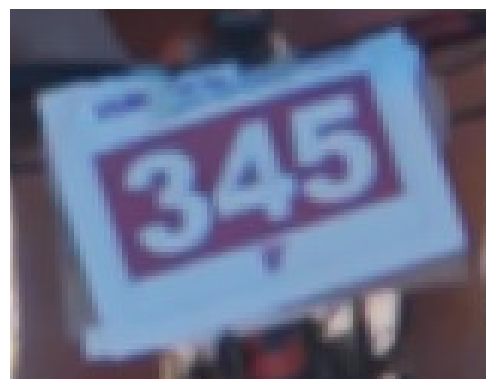

In [7]:
crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
plt.imshow(crop)
plt.axis("off")
plt.show()